# LAB BASK — Modulação e Demodulação Binária ASK
**Disciplina:** Sistemas de Comunicação — Engenharia Eletrônica (IFSC)

## Contexto

Você vai implementar, **do zero**, um sistema completo de comunicação BASK —
da fonte ao destino — usando como referência apenas o diagrama de blocos e
as equações apresentadas em aula (função-base Ψ1(t), bloco correlator,
bloco de decisão). Este notebook **não contém código-base**: as células de
código abaixo estão propositalmente vazias, com apenas um comentário
indicando o que deve ser implementado ali.

O objetivo não é "ter um código que funciona", e sim conseguir justificar,
bloco por bloco, por que ele funciona — inclusive quando a saída não bate
com o esperado.

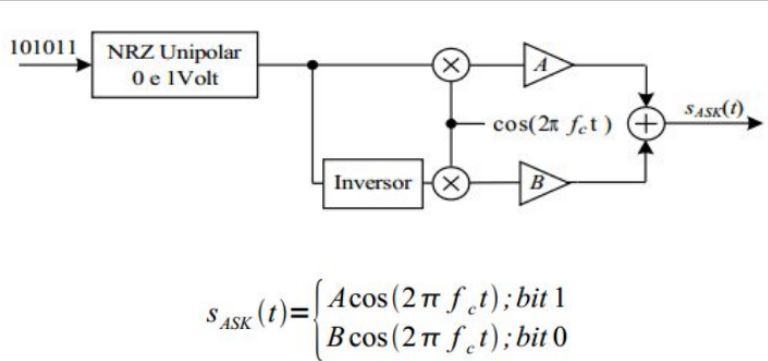


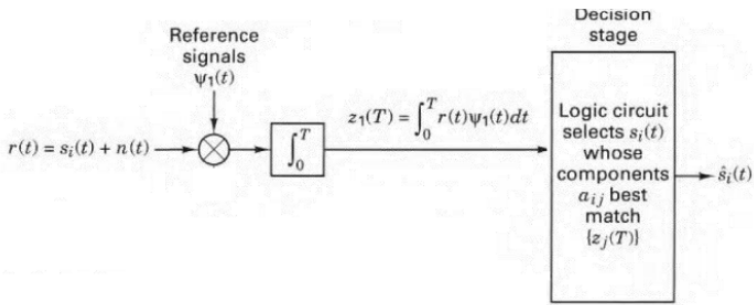


## Parâmetros da sua implementação (individualizados)

Antes de começar, gere seus parâmetros a partir dos **dois últimos dígitos
da sua matrícula** (`M`). Preencha `M` na célula de código abaixo e rode —
os parâmetros derivados dela (frequência da portadora, amplitude do pulso e
semente da sequência de bits) devem ser usados em **todo o resto do
notebook**.

In [1]:
# Preencha com os dois últimos dígitos da sua matrícula
M = 75

# --- parâmetros individualizados (não alterar as fórmulas) ---
# fc = 1000 + 100*M          (Hz)
# A  = 3 + (M % 5)           (V)
# seed = M                    (para gerar a sequência de bits aleatória)

fc = 1000 + 100*M
A = 3 + (M % 5)
seed = M

print(f"fc = {fc} Hz | A = {A} V | seed = {seed}")

fc = 8500 Hz | A = 3 V | seed = 75


## Etapa 1 — Dedução teórica (antes de qualquer código)

Antes de escrever qualquer linha de Python, deduza **manualmente** (nesta
célula markdown, em LaTeX ou texto claro):

1. A energia por bit `Eb` para o seu esquema (considerando os **dois níveis
   de amplitude** do sinal — bit=1 e bit=0 — e não a fórmula genérica de ASK
   on-off);
2. O **limiar de decisão ideal**, a partir das saídas esperadas do
   correlator para bit=1 e bit=0. Mostre a conta completa, não só o número
   final;
3. A **largura de banda nula-a-nula** esperada (`2/Tb`) para o seu `Tb` (escolha um bitrate!).

Este é um entregável avaliado separadamente do código — serve para garantir
que o limiar usado mais adiante no bloco de decisão não é um número
escolhido "no olho", e sim algo que você sabe justificar.

### Dedução teórica

Escolho a taxa de bits:

$$
R_b = 1\,\text{kbit/s}
$$

Logo,

$$
T_b = \frac{1}{R_b}=1\,\text{ms}
$$

Para uma BASK com dois níveis de amplitude, os sinais correspondentes
aos bits 1 e 0 são:

$$
s_1(t)=A\cos(2\pi f_ct)
$$

$$
s_0(t)=B\cos(2\pi f_ct)
$$

A energia do símbolo correspondente ao bit 1 é:

$$
E_1=\int_0^{T_b}s_1^2(t)\,dt
$$

$$
E_1=
A^2\int_0^{T_b}\cos^2(2\pi f_ct)\,dt
$$

Considerando um número inteiro de ciclos da portadora durante $T_b$:

$$
\int_0^{T_b}\cos^2(2\pi f_ct)\,dt
=\frac{T_b}{2}
$$

Portanto:

$$
E_1=\frac{A^2T_b}{2}
$$

Analogamente, para o bit 0:

$$
E_0=\int_0^{T_b}s_0^2(t)\,dt
=\frac{B^2T_b}{2}
$$

Como os bits são equiprováveis, a energia média por bit é:

$$
E_b=\frac{E_1+E_0}{2}
$$

Logo:

$$
\boxed{
E_b=\frac{A^2+B^2}{4}T_b
}
$$

Na implementação desta atividade, o nível correspondente ao bit 0 é
$B=0$. Portanto:

$$
E_b=\frac{A^2T_b}{4}
$$

Como $A=3\,V$ e $T_b=1\,ms$:

$$
E_b=
\frac{3^2(10^{-3})}{4}
$$

$$
\boxed{
E_b=2.25\times10^{-3}
}
$$

---

Para a demodulação coerente, utilizamos a função-base normalizada:

$$
\Psi_1(t)=
\sqrt{\frac{2}{T_b}}\cos(2\pi f_ct)
$$

O correlator calcula:

$$
z_1(T_b)=
\int_0^{T_b}r(t)\Psi_1(t)\,dt
$$

Sem ruído, para o bit 1:

$$
z_1^{(1)}
=
\int_0^{T_b}s_1(t)\Psi_1(t)\,dt
$$

$$
z_1^{(1)}
=
A\sqrt{\frac{2}{T_b}}
\int_0^{T_b}\cos^2(2\pi f_ct)\,dt
$$

$$
z_1^{(1)}
=
A\sqrt{\frac{2}{T_b}}\frac{T_b}{2}
$$

portanto:

$$
\boxed{
z_1^{(1)}=
A\sqrt{\frac{T_b}{2}}
}
$$

Para o bit 0, no caso geral:

$$
z_1^{(0)}
=
B\sqrt{\frac{T_b}{2}}
$$

Como nesta implementação $B=0$:

$$
\boxed{
z_1^{(0)}=0
}
$$

O limiar de decisão é definido como o ponto médio entre as duas
saídas esperadas do correlator:

$$
\gamma=
\frac{z_1^{(1)}+z_1^{(0)}}{2}
$$

Substituindo as expressões anteriores:

$$
\gamma=
\frac{A+B}{2}\sqrt{\frac{T_b}{2}}
$$

Como $B=0$:

$$
\boxed{
\gamma=
\frac{A}{2}\sqrt{\frac{T_b}{2}}
}
$$

Para $A=3\,V$ e $T_b=1\,ms$:

$$
\gamma=
\frac{3}{2}\sqrt{\frac{10^{-3}}{2}}
$$

$$
\boxed{
\gamma\approx0.03354
}
$$

Assim, no bloco de decisão:

$$
z_1(T_b)>\gamma
\Rightarrow \hat{b}=1
$$

$$
z_1(T_b)\leq\gamma
\Rightarrow \hat{b}=0
$$

---

Finalmente, a largura de banda nula-a-nula esperada é:

$$
B_{\text{nula-a-nula}}=\frac{2}{T_b}
$$

Como $T_b=1\,ms$:

$$
B_{\text{nula-a-nula}}
=
\frac{2}{10^{-3}}
$$

$$
\boxed{
B_{\text{nula-a-nula}}=2\,\text{kHz}
}
$$

## Etapa 2 — Implementação: Fonte → Transmissor → Canal → Receptor → Destino

Com base nos blocos do diagrama apresentados acima, implemente cada bloco
em uma célula separada. Ao final desta etapa você deve conseguir:

- Gerar a sequência de bits (fonte);
- Modular em BASK (transmissor);
- Mostrar **s(t) no tempo e na frequência**, relacionando visualmente a
  banda ocupada com o valor de `2/Tb` calculado na Etapa 1;
- Demodular via correlator coerente - multiplicação pela mesma função base (portadora), usando o **limiar deduzido na Etapa 1**
  (não um valor arbitrário).

In [2]:
# --- Bloco: Fonte ---

import numpy as np

# Número de bits da mensagem
N_bits = 20

# Inicializa o gerador com a semente individualizada
rng = np.random.default_rng(seed)

# Gera a sequência de bits
bits = rng.integers(0, 2, size=N_bits)

print("Bits transmitidos:")
print(bits)

Bits transmitidos:
[1 0 0 0 1 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0]


In [3]:
# --- Bloco: Transmissor (modulador BASK) ---

# Taxa de amostragem
fs = 100_000  # Hz

# Período e duração de cada bit
Rb = 1_000    # bit/s
Tb = 1 / Rb

# Número de amostras por bit
Ns = int(fs * Tb)

# Tempo total do sinal
t = np.arange(N_bits * Ns) / fs

# Sinal NRZ: cada bit permanece constante durante Tb
nrz = np.repeat(bits, Ns)

# Portadora
carrier = np.cos(2 * np.pi * fc * t)

# Modulação BASK/OOK
# Bit 1 -> amplitude A
# Bit 0 -> amplitude B = 0
s = A * nrz * carrier

print(f"fs = {fs} Hz")
print(f"Tb = {Tb*1000:.2f} ms")
print(f"Amostras por bit = {Ns}")
print(f"Duração total = {t[-1] + 1/fs:.4f} s")

fs = 100000 Hz
Tb = 1.00 ms
Amostras por bit = 100
Duração total = 0.0200 s


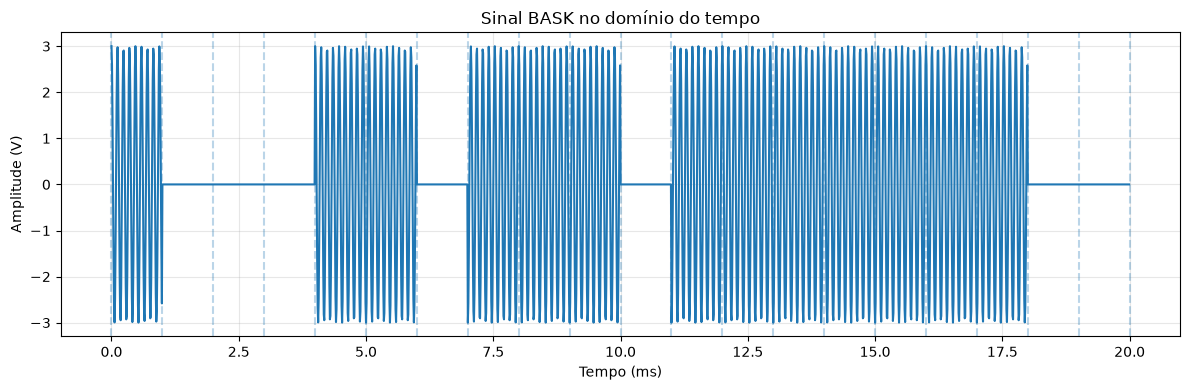

In [4]:
# --- Visualização: s(t) no tempo ---

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.plot(t * 1000, s)

plt.xlabel("Tempo (ms)")
plt.ylabel("Amplitude (V)")
plt.title("Sinal BASK no domínio do tempo")

# Linhas verticais indicando os limites dos bits
for k in range(N_bits + 1):
    plt.axvline(k * Tb * 1000, linestyle="--", alpha=0.3)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

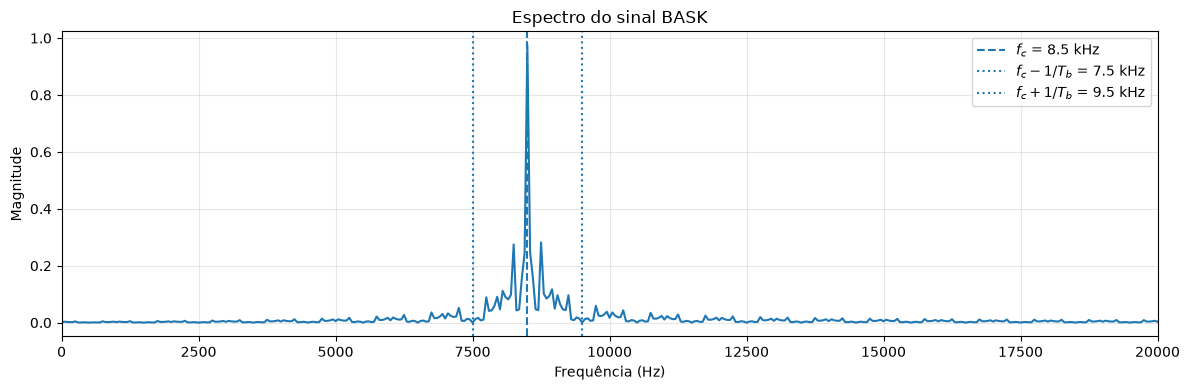

f_c = 8500 Hz
2/Tb = 2000.0 Hz
Banda teórica: 7500.0 Hz a 9500.0 Hz


In [5]:
# --- Visualização: espectro de s(t) (FFT) ---

# FFT do sinal
S = np.fft.fft(s)

# Frequências correspondentes às amostras da FFT
freq = np.fft.fftfreq(len(s), d=1/fs)

# Magnitude normalizada
S_mag = np.abs(S) / len(s)

# Mantém apenas as frequências positivas
positive = freq >= 0

freq_pos = freq[positive]
S_mag_pos = S_mag[positive]

# Banda teórica nula-a-nula
BW_teorica = 2 / Tb

# Limites teóricos em torno da portadora
f_lower = fc - 1 / Tb
f_upper = fc + 1 / Tb

plt.figure(figsize=(12, 4))

plt.plot(freq_pos, S_mag_pos)

# Marca a frequência da portadora
plt.axvline(
    fc,
    linestyle="--",
    label=f"$f_c$ = {fc/1000:.1f} kHz"
)

# Marca os limites da banda teórica
plt.axvline(
    f_lower,
    linestyle=":",
    label=f"$f_c - 1/T_b$ = {f_lower/1000:.1f} kHz"
)

plt.axvline(
    f_upper,
    linestyle=":",
    label=f"$f_c + 1/T_b$ = {f_upper/1000:.1f} kHz"
)

plt.xlim(0, 20_000)

plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.title("Espectro do sinal BASK")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"f_c = {fc} Hz")
print(f"2/Tb = {BW_teorica} Hz")
print(f"Banda teórica: {f_lower} Hz a {f_upper} Hz")

In [6]:
# --- Bloco: Canal (ideal, sem ruído nesta etapa) ---

# Canal ideal: não altera o sinal transmitido
r = s.copy()

print("Canal ideal aplicado.")
print(f"Máximo do sinal recebido: {np.max(r):.2f} V")
print(f"Mínimo do sinal recebido: {np.min(r):.2f} V")

Canal ideal aplicado.
Máximo do sinal recebido: 3.00 V
Mínimo do sinal recebido: -3.00 V


In [7]:
# --- Bloco: Receptor — Correlator ---

# Função-base normalizada
psi1 = np.sqrt(2 / Tb) * np.cos(2 * np.pi * fc * t)

# Intervalo de amostragem
dt = 1 / fs

# Saída do correlator para cada bit
z = np.zeros(N_bits)

for k in range(N_bits):
    # Índices correspondentes ao bit k
    start = k * Ns
    end = (k + 1) * Ns

    # Trecho do sinal recebido e da função-base
    r_bit = r[start:end]
    psi_bit = psi1[start:end]

    # Correlação = integral r(t) * psi1(t) dt
    z[k] = np.sum(r_bit * psi_bit) * dt

print("Saída do correlator:")
print(np.round(z, 5))

Saída do correlator:
[0.06708 0.      0.      0.      0.06708 0.06708 0.      0.06708 0.06708
 0.06708 0.      0.06708 0.06708 0.06708 0.06708 0.06708 0.06708 0.06708
 0.      0.     ]


In [8]:
# --- Bloco: Decisão ---

# Limiar deduzido teoricamente na Etapa 1
gamma = (A / 2) * np.sqrt(Tb / 2)

# Decisão para cada bit
bits_hat = (z > gamma).astype(int)

print(f"Limiar teórico γ = {gamma:.5f}")
print("Bits transmitidos:")
print(bits)
print("Bits detectados:")
print(bits_hat)

# Verificação
erros = np.sum(bits != bits_hat)

print(f"Número de erros: {erros}")

Limiar teórico γ = 0.03354
Bits transmitidos:
[1 0 0 0 1 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0]
Bits detectados:
[1 0 0 0 1 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0]
Número de erros: 0


Os bits detectados foram idênticos aos bits originalmente transmitidos, resultando em 0 erros. Isso é esperado, pois nesta etapa foi utilizado um canal ideal, sem ruído ou atenuação. O correlator produziu valores próximos de 0 para o bit 0 e de 0,06708 para o bit 1, permitindo que o limiar teórico gamma=0,03354 separasse corretamente os dois níveis. Portanto, não há indícios de erro nos blocos de transmissão, canal, correlator ou decisão nesta etapa.

## Etapa 3 — Canal com ruído (AWGN) e curva de BER

- Adicione ruído gaussiano ao canal, variando a relação sinal-ruído (Eb/No).
- Simule a Taxa de Erro de Bit (BER) para uma faixa de Eb/No.
- Plote a curva simulada **contra a curva teórica de BASK**.
- Comente onde a curva simulada diverge da teórica e por quê (número de
  bits simulados, natureza do ruído gerado, etc.).

In [9]:
# --- Canal com ruído AWGN ---

# Eb/N0 desejado
EbN0_dB = 6

# Energia média por bit (calculada na Etapa 1)
Eb = (A**2 * Tb) / 4

# Converte Eb/N0 de dB para escala linear
EbN0 = 10**(EbN0_dB / 10)

# Densidade espectral de potência do ruído
N0 = Eb / EbN0

# Desvio padrão do ruído AWGN amostrado
sigma_n = np.sqrt(N0 * fs / 2)

# Geração do ruído
rng_awgn = np.random.default_rng(seed + 1)
noise = rng_awgn.normal(0, sigma_n, size=len(s))

# Sinal recebido
r_awgn = s + noise

print(f"Eb = {Eb:.6e}")
print(f"Eb/N0 = {EbN0_dB} dB")
print(f"N0 = {N0:.6e}")
print(f"σ_n = {sigma_n:.4f} V")

Eb = 2.250000e-03
Eb/N0 = 6 dB
N0 = 5.651744e-04
σ_n = 5.3159 V


In [10]:
# --- Simulação de BER para uma faixa de SNR ---

from scipy.special import erfc

# Parâmetros da simulação
N_bits_BER = 100_000
EbN0_dB_range = np.arange(0, 11, 1)

# Gerador aleatório reprodutível
rng_ber = np.random.default_rng(seed + 2)

# Sequência de bits
bits_ber = rng_ber.integers(0, 2, size=N_bits_BER)

# Energia média por bit
Eb = (A**2 * Tb) / 4

# Tempo global
t_ber = np.arange(N_bits_BER * Ns) / fs

# Sinal NRZ
nrz_ber = np.repeat(bits_ber, Ns)

# Portadora e função-base com fase global
carrier_ber = np.cos(2 * np.pi * fc * t_ber)
psi_ber = np.sqrt(2 / Tb) * carrier_ber

# Sinal BASK
s_ber = A * nrz_ber * carrier_ber

# Organiza em uma matriz: uma linha por bit
psi_matrix = psi_ber.reshape(N_bits_BER, Ns)

# Resultados
BER_simulada = []
BER_teorica = []

# Limiar teórico
gamma = (A / 2) * np.sqrt(Tb / 2)

for EbN0_dB in EbN0_dB_range:

    # Eb/N0 em escala linear
    EbN0 = 10**(EbN0_dB / 10)

    # Densidade espectral de potência
    N0 = Eb / EbN0

    # Desvio padrão do AWGN amostrado
    sigma_n = np.sqrt(N0 * fs / 2)

    # Gera AWGN
    noise = rng_ber.normal(0, sigma_n, size=len(s_ber))

    # Sinal recebido
    r_ber = s_ber + noise

    # Organiza o sinal em uma matriz, uma linha por bit
    r_matrix = r_ber.reshape(N_bits_BER, Ns)

    # Correlator
    z_ber = np.sum(r_matrix * psi_matrix, axis=1) * (1 / fs)

    # Decisão
    bits_hat_ber = (z_ber > gamma).astype(int)

    # BER simulada
    erros = np.sum(bits_hat_ber != bits_ber)
    ber = erros / N_bits_BER

    BER_simulada.append(ber)

    # BER teórica para BASK/OOK coerente
    ber_teorica = 0.5 * erfc(np.sqrt(EbN0))
    BER_teorica.append(ber_teorica)

    print(
        f"Eb/N0 = {EbN0_dB:2d} dB | "
        f"Erros = {erros:5d} | "
        f"BER = {ber:.6e}"
    )

Eb/N0 =  0 dB | Erros = 15776 | BER = 1.577600e-01
Eb/N0 =  1 dB | Erros = 13090 | BER = 1.309000e-01
Eb/N0 =  2 dB | Erros = 10372 | BER = 1.037200e-01
Eb/N0 =  3 dB | Erros =  7797 | BER = 7.797000e-02
Eb/N0 =  4 dB | Erros =  5666 | BER = 5.666000e-02
Eb/N0 =  5 dB | Erros =  3740 | BER = 3.740000e-02
Eb/N0 =  6 dB | Erros =  2350 | BER = 2.350000e-02
Eb/N0 =  7 dB | Erros =  1283 | BER = 1.283000e-02
Eb/N0 =  8 dB | Erros =   586 | BER = 5.860000e-03
Eb/N0 =  9 dB | Erros =   207 | BER = 2.070000e-03
Eb/N0 = 10 dB | Erros =    70 | BER = 7.000000e-04


In [11]:
# --- Curva teórica de BER para BASK, para comparação ---

# Conversão de Eb/N0 de dB para escala linear
EbN0_linear = 10**(EbN0_dB_range / 10)

# BER teórica para BASK/OOK coerente
BER_teorica = 0.5 * erfc(np.sqrt(EbN0_linear / 2))

print("Eb/N0 (dB) | BER teórica")
print("------------------------")

for snr, ber in zip(EbN0_dB_range, BER_teorica):
    print(f"{snr:9.0f} | {ber:.6e}")

Eb/N0 (dB) | BER teórica
------------------------
        0 | 1.586553e-01
        1 | 1.309273e-01
        2 | 1.040286e-01
        3 | 7.889587e-02
        4 | 5.649530e-02
        5 | 3.767899e-02
        6 | 2.300714e-02
        7 | 1.258703e-02
        8 | 6.004386e-03
        9 | 2.413310e-03
       10 | 7.827011e-04


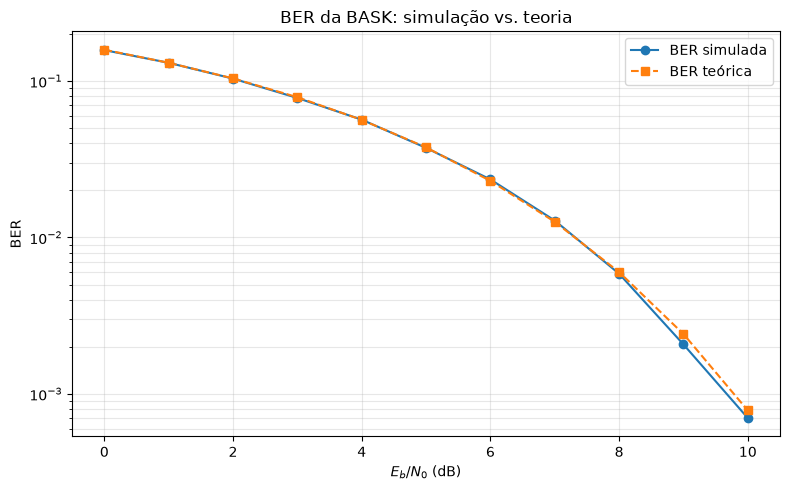

In [12]:
# --- Curva de BER: simulada x teórica ---

plt.figure(figsize=(8, 5))

plt.semilogy(
    EbN0_dB_range,
    BER_simulada,
    'o-',
    label='BER simulada'
)

plt.semilogy(
    EbN0_dB_range,
    BER_teorica,
    's--',
    label='BER teórica'
)

plt.xlabel(r'$E_b/N_0$ (dB)')
plt.ylabel('BER')
plt.title('BER da BASK: simulação vs. teoria')

plt.grid(True, which='both', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

A curva simulada apresentou boa concordância com a curva teórica em toda a faixa de Eb/N0 analisada. As maiores diferenças aparecem nos valores mais altos de Eb/N0, onde a BER é menor. Essa divergência é atribuída principalmente ao número finito de bits utilizados na simulação (100.000 bits). Como a quantidade de erros observados se torna pequena em altos valores de Eb/N0, a estimativa da BER fica mais sujeita à variação estatística. Além disso, o ruído AWGN é uma realização aleatória, portanto cada simulação pode produzir pequenas diferenças em relação ao valor teórico. Com um número maior de bits, a estimativa simulada tenderia a se aproximar ainda mais da curva teórica.

## Etapa 4 — Detecção coerente vs. não-coerente (envoltória)

- Implemente também um **detector por envoltória** (não-coerente) para o
  mesmo sinal.
- Compare o desempenho dos dois métodos (BER) no mesmo cenário de ruído.

In [13]:
# --- Detector por envoltória (não-coerente) ---

from scipy.signal import hilbert

# Utiliza o mesmo sinal ruidoso da simulação anterior (Eb/N0 = 6 dB)
# r_awgn foi gerado na célula do canal AWGN

# Obtém o sinal analítico e sua envoltória
analytic_signal = hilbert(r_awgn)
envelope = np.abs(analytic_signal)

# Média da envoltória em cada intervalo de bit
envelope_matrix = envelope.reshape(N_bits, Ns)
envelope_mean = np.mean(envelope_matrix, axis=1)

# Limiar de decisão
gamma_env = A / 2

# Decisão
bits_hat_env = (envelope_mean > gamma_env).astype(int)

# BER
erros_env = np.sum(bits_hat_env != bits)
BER_env = erros_env / N_bits

print(f"Limiar do detector = {gamma_env:.2f} V")
print("Bits transmitidos:")
print(bits)
print("Bits detectados pela envoltória:")
print(bits_hat_env)
print(f"Número de erros: {erros_env}")
print(f"BER do detector por envoltória: {BER_env:.4f}")

Limiar do detector = 1.50 V
Bits transmitidos:
[1 0 0 0 1 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0]
Bits detectados pela envoltória:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Número de erros: 7
BER do detector por envoltória: 0.3500


In [14]:
# --- BER: coerente vs. não-coerente, mesmo cenário de ruído ---

# Detector coerente (correlator)
psi1 = np.sqrt(2 / Tb) * np.cos(2 * np.pi * fc * t)

z_awgn = np.zeros(N_bits)

for k in range(N_bits):
    start = k * Ns
    end = (k + 1) * Ns

    z_awgn[k] = np.sum(
        r_awgn[start:end] * psi1[start:end]
    ) * (1 / fs)

# Limiar do detector coerente
gamma_coerente = (A / 2) * np.sqrt(Tb / 2)

bits_hat_coerente = (z_awgn > gamma_coerente).astype(int)

# BER do detector coerente
erros_coerente = np.sum(bits_hat_coerente != bits)
BER_coerente = erros_coerente / N_bits

print(f"BER coerente:     {BER_coerente:.4f} ({erros_coerente} erros)")
print(f"BER não-coerente: {BER_env:.4f} ({erros_env} erros)")

BER coerente:     0.0500 (1 erros)
BER não-coerente: 0.3500 (7 erros)


Os dois métodos apresentaram desempenhos diferentes porque o detector coerente utiliza o conhecimento da frequência e da fase da portadora para realizar a correlação com o sinal recebido. Dessa forma, ele consegue concentrar a energia do sinal na saída do correlator e separar melhor os bits do ruído. Já o detector por envoltória não necessita conhecer a fase da portadora, mas a presença do ruído altera diretamente a envoltória estimada, dificultando a distinção entre os níveis 0 e 1.

Neste cenário, o detector coerente apresentou BER de 0,05 (1 erro em 20 bits), enquanto o detector por envoltória apresentou BER de 0,35 (7 erros em 20 bits). Portanto, nesta realização do ruído, o detector coerente apresentou menos erros. Como foram utilizados apenas 20 bits, esses valores possuem uma grande variação estatística e não devem ser considerados uma comparação definitiva de desempenho.

## Etapa 5 — Perguntas "e se...?"

Responda cada pergunta com raciocínio próprio. Se quiser, use código nas
células abaixo para testar suas hipóteses antes de escrever a resposta
final na célula markdown correspondente.

**a) O que acontece com a BER se `fc` dobrar, mantendo
`Tb` fixo?**

**Resposta:**

Se $f_c$ dobrar, mantendo $T_b$ fixo, a BER teórica não deve se alterar,
desde que a frequência de amostragem seja suficiente e o receptor esteja
sincronizado com a nova frequência da portadora.

Isso ocorre porque, mantendo $A$ e $T_b$ constantes, a energia média por
bit também permanece constante:

$$
E_b=\frac{A^2T_b}{4}
$$

Como a BER depende de $E_b/N_0$, e não diretamente da frequência da
portadora, seu valor teórico permanece o mesmo.

O que muda é a posição do sinal no espectro. A portadora passa de

$$
f_c=8,5\,\text{kHz}
$$

para

$$
f_c=17\,\text{kHz}
$$

enquanto a largura de banda permanece aproximadamente
$2/T_b=2\,\text{kHz}$.

Portanto, neste caso, dobrar $f_c$ desloca o sinal para uma frequência
maior, mas não altera a BER, desde que não sejam violadas as condições
de amostragem e sincronização.

In [15]:
# --- Teste: dobrando a frequência da portadora ---

fc_teste = 2 * fc

# Nova portadora
carrier_teste = np.cos(2 * np.pi * fc_teste * t)

# Novo sinal BASK
s_teste = A * nrz * carrier_teste

# Mesmo cenário de ruído: Eb/N0 = 6 dB
EbN0_dB_teste = 6
EbN0_teste = 10**(EbN0_dB_teste / 10)
N0_teste = Eb / EbN0_teste
sigma_n_teste = np.sqrt(N0_teste * fs / 2)

# Gera ruído com a mesma distribuição, mas usando uma nova realização
rng_teste = np.random.default_rng(seed + 3)
noise_teste = rng_teste.normal(0, sigma_n_teste, size=len(s_teste))

r_teste = s_teste + noise_teste

# Referência coerente usando a nova frequência
psi_teste = np.sqrt(2 / Tb) * np.cos(2 * np.pi * fc_teste * t)

# Correlator
z_teste = np.zeros(N_bits)

for k in range(N_bits):
    start = k * Ns
    end = (k + 1) * Ns

    z_teste[k] = np.sum(
        r_teste[start:end] * psi_teste[start:end]
    ) * (1 / fs)

# Decisão
gamma_teste = (A / 2) * np.sqrt(Tb / 2)
bits_hat_teste = (z_teste > gamma_teste).astype(int)

# BER
erros_teste = np.sum(bits_hat_teste != bits)
BER_teste = erros_teste / N_bits

print(f"fc original = {fc/1000:.1f} kHz")
print(f"fc dobrada  = {fc_teste/1000:.1f} kHz")
print(f"Eb/N0       = {EbN0_dB_teste} dB")
print(f"Erros       = {erros_teste}")
print(f"BER         = {BER_teste:.4f}")

fc original = 8.5 kHz
fc dobrada  = 17.0 kHz
Eb/N0       = 6 dB
Erros       = 1
BER         = 0.0500


**b) O que acontece com o limiar de decisão se as duas
amplitudes do esquema (bit=1 e bit=0) forem trocadas por valores mais
próximos entre si? Em que ponto o sistema deixa de ser confiável?**

**Resposta:**

Quando as amplitudes dos bits 1 e 0 ficam mais próximas, o limiar de
decisão também se desloca para mais perto dos dois níveis. Entretanto,
o principal efeito é a redução da distância entre as duas possíveis
saídas do correlator:

$$
\Delta z=(A-B)\sqrt{\frac{T_b}{2}}
$$

Com menor distância entre os níveis, o ruído tem maior probabilidade de
fazer o sinal ultrapassar o limiar, aumentando a BER.

O teste realizado com $A=3$ V e $E_b/N_0=6$ dB mostrou essa tendência:
para $B=0$ V a BER foi 0, enquanto para $B=2,5$ V foi 0,20 e para
$B=2,9$ V chegou a 0,35. Como foram utilizados apenas 20 bits, esses
valores podem variar de uma realização do ruído para outra.

O sistema perde a capacidade de distinguir os bits no limite em que
$A=B$. Nesse caso, os dois sinais são iguais, a distância entre os
níveis é zero e a informação binária não pode mais ser recuperada pelo
receptor.

In [16]:
# --- Teste: aproximando as amplitudes A e B ---

B_valores = [0, 1, 2, 2.5, 2.9]

# Ruído para os 20 bits do teste
EbN0_dB_teste = 6
EbN0_teste = 10**(EbN0_dB_teste / 10)
N0_teste = Eb / EbN0_teste
sigma_n_teste = np.sqrt(N0_teste * fs / 2)

rng_teste = np.random.default_rng(seed + 4)
noise_teste = rng_teste.normal(0, sigma_n_teste, size=len(t))

# Portadora e referência
carrier_bask = np.cos(2 * np.pi * fc * t)
psi_bask = np.sqrt(2 / Tb) * carrier_bask

print(" A (V) | B (V) | Limiar | BER")
print("--------------------------------")

for B_teste in B_valores:

    # Amplitude de cada bit
    amplitude = A * bits + B_teste * (1 - bits)

    # Expande cada bit para Ns amostras
    nrz_bask = np.repeat(amplitude, Ns)

    # Sinal BASK
    s_bask = nrz_bask * carrier_bask

    # Canal AWGN
    r_bask = s_bask + noise_teste

    # Correlator
    z_bask = np.zeros(N_bits)

    for k in range(N_bits):
        start = k * Ns
        end = (k + 1) * Ns

        z_bask[k] = np.sum(
            r_bask[start:end] * psi_bask[start:end]
        ) * (1 / fs)

    # Limiar entre os dois níveis
    gamma_bask = ((A + B_teste) / 2) * np.sqrt(Tb / 2)

    # Decisão
    bits_hat_bask = (z_bask > gamma_bask).astype(int)

    # BER
    erros_bask = np.sum(bits_hat_bask != bits)
    BER_bask = erros_bask / N_bits

    print(
        f"{A:6.1f} | {B_teste:5.1f} | "
        f"{gamma_bask:6.4f} | {BER_bask:.4f}"
    )

 A (V) | B (V) | Limiar | BER
--------------------------------
   3.0 |   0.0 | 0.0335 | 0.0000
   3.0 |   1.0 | 0.0447 | 0.0000
   3.0 |   2.0 | 0.0559 | 0.0500
   3.0 |   2.5 | 0.0615 | 0.2000
   3.0 |   2.9 | 0.0660 | 0.3500


**c) Qual é o modo de falha mais provável do seu
receptor se o `fs` escolhido violar o critério de Nyquist para `fc`?**

**Resposta:**

Se o $f_s$ escolhido violar o critério de Nyquist para $f_c$, o modo
de falha mais provável é o **aliasing**.

Para representar corretamente a portadora, deve-se ter:

$$
f_s > 2f_c
$$

No nosso caso:

$$
2f_c=17\,\text{kHz}
$$

e foi realizado um teste com $f_s=12\,\text{kHz}$. Nesse caso, a
frequência de Nyquist é:

$$
f_N=\frac{f_s}{2}=6\,\text{kHz}
$$

Como $f_c>f_N$, a portadora sofre aliasing e aparece no sinal
amostrado em uma frequência diferente da original. No teste, a
frequência observada foi aproximadamente:

$$
f_{\text{alias}}=|f_s-f_c|
=|12-8,5|
=3,5\,\text{kHz}
$$

Isso pode ser observado no espectro obtido na simulação, que apresenta
um pico próximo de $3,5$ kHz em vez da portadora original de $8,5$ kHz.

Como o receptor coerente utiliza a portadora original como referência,
essa alteração prejudica a correlação entre o sinal recebido e a
função-base, podendo provocar decisões incorretas e aumento da BER.

Portanto, a violação de Nyquist pode fazer o receptor trabalhar com uma
representação incorreta da portadora devido ao aliasing.

In [17]:
# --- Teste: aliasing por amostragem abaixo de Nyquist ---

fs_original = 100_000  # amostragem suficientemente alta
fs_teste = 12_000      # amostragem abaixo de 2*fc

# Sinal original em alta taxa de amostragem
Ns_original = int(fs_original * Tb)
t_original = np.arange(N_bits * Ns_original) / fs_original

nrz_original = np.repeat(bits, Ns_original)

carrier_original = np.cos(2 * np.pi * fc * t_original)

s_original = A * nrz_original * carrier_original

# --- Amostragem inadequada ---
# Mantemos aproximadamente o mesmo instante inicial
t_amostrado = np.arange(
    0,
    t_original[-1],
    1 / fs_teste
)

nrz_amostrado = np.repeat(bits, int(fs_teste * Tb))

carrier_amostrado = np.cos(2 * np.pi * fc * t_amostrado)

s_amostrado = (
    A * nrz_amostrado[:len(t_amostrado)]
    * carrier_amostrado
)

print(f"fc = {fc/1000:.1f} kHz")
print(f"fs original = {fs_original/1000:.1f} kHz")
print(f"fs teste = {fs_teste/1000:.1f} kHz")
print(f"2*fc = {2*fc/1000:.1f} kHz")

fc = 8.5 kHz
fs original = 100.0 kHz
fs teste = 12.0 kHz
2*fc = 17.0 kHz


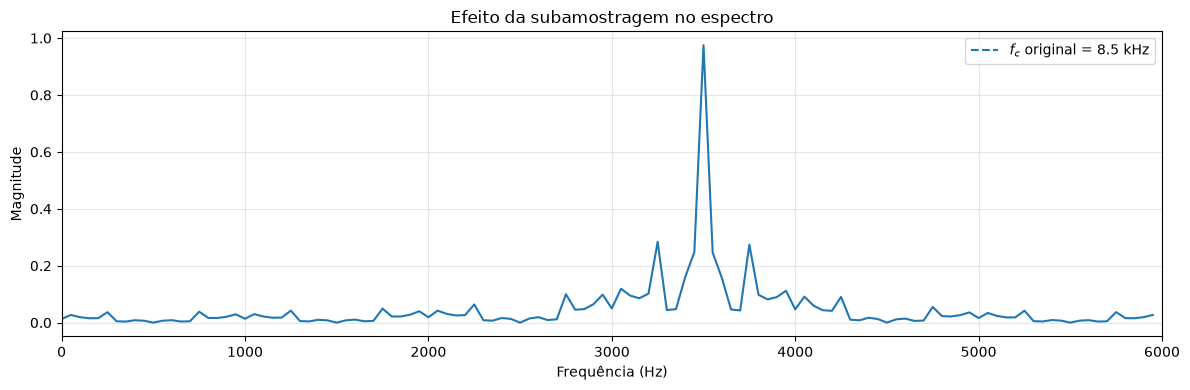

In [18]:
# --- Espectro do sinal subamostrado ---

S_alias = np.fft.fft(s_amostrado)
freq_alias = np.fft.fftfreq(len(s_amostrado), d=1/fs_teste)

positive = freq_alias >= 0

plt.figure(figsize=(12, 4))

plt.plot(
    freq_alias[positive],
    np.abs(S_alias[positive]) / len(s_amostrado)
)

plt.axvline(
    fc,
    linestyle="--",
    label=f"$f_c$ original = {fc/1000:.1f} kHz"
)

plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.title("Efeito da subamostragem no espectro")
plt.xlim(0, fs_teste / 2)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Log de uso de IA

Preencha esta seção conforme for usando alguma LLM ao longo do trabalho
(não precisa ser só no final). Trate isso como citação de fonte, não como
delação: o objetivo é registrar como a ferramenta foi usada, não evitar
usá-la.

| Prompt usado | Onde foi aplicado (etapa/bloco) | O que foi aproveitado literalmente | O que você corrigiu ou adaptou, e por quê |
|---|---|---|---|
| Vamos deduzier a Eb, o limiar de decisão e a largura de banda nula, mantendo Q nas contas e somente depois substituindo Q como 0 | Etapa 1 | Somente o markdown das equações | |
| Ja tendo os resultados de fc, A e seed, vamos gerar uma sequencia de bits | Etapa 2 | O código | |
| Agora vamos pegar essa sequencia e construir o sinal NRZ e o sinal modulado | Etapa 2 | O código | |
| Vamos fazer o plot desse s(t) no tempo | Etapa 2 | O código | |
| Fazer o espectro fft desse mesmo sinal | Etapa 2 | O código | |
| Certinho. Agora uma célula que atua como o canal. nesse momento ideal. | Etapa 2 | O código | |
| Agora o correlator. Vamos multiplicar o sinal pela função base e intefrar pelo intervalo de bits também | Etapa 2 | O código | |
| Agora o bloco de decisão. Usar aquele mesmo limiar que deduzimos na etapa 1 | Etapa 2 | O código | |
| Blz. A primeira coisa na próxima etapa é fazer um canal que apresenta ruido AWGN | Etapa 3 | O código | |
| Vamos verificar a BER com valores diferentes de Eb/No | Etapa 3 | O código | Tinha um erro em uma das linhas que reiniciava a fase |
| Agora vamos fazer uma curva teórica para comparar com os resultados obtidos | Etapa 3 | O código | Tinha um erro em uma das linhas. Faltava dividir Eb/No por 2 |
| Agora plote os resultados obtidos com a teórica | Etapa 3 | O código | |
| Na etapa seguinte a gente vai fazer um detectorpor envoltória não coerente e um coerente para verificar a diferença entre os dois. Primeiro vamos vazer o não coerente. | Etapa 4 | O código | |
| Agora vamos comparar os dois com o mesmo cenário de ruido. | Etapa 4 | O código | |
| (Em todas as partes da etapa 5 eu dei a minha resposta para o IA para reformatar elas e gerar códigos de teste para verificar se fazia sentido) | | | |


## Entregáveis

1. Este notebook preenchido (dedução teórica, código comentado, gráficos e
   respostas em markdown);
2. Log de uso de IA preenchido acima;
